#Cell 1 — Imports

In [1]:
from __future__ import annotations

# Core
import os
import math
from dataclasses import dataclass

# Numeric
import numpy as np

# Plot
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # needed for 3D plotting

# Video
import cv2

#Cell 2 — Output folder

In [2]:
# Output directory
BASE_DIR = "./outputs/"
os.makedirs(BASE_DIR, exist_ok=True)

#Cell 3 — Helpers

In [3]:
def unit_vector(v: np.ndarray, eps: float = 1e-9) -> np.ndarray:
    # Safe normalization
    n = np.linalg.norm(v, axis=-1, keepdims=True)
    return v / (n + eps)


def normalize(v: np.ndarray, eps: float = 1e-9) -> np.ndarray:
    # Safe normalization for 1D vectors
    return v / (np.linalg.norm(v) + eps)

#Cell 4 — Fish simulator

In [4]:
class FishTankSim:
    # Tank coordinates: x in [0, Lx], y in [0, Ly], z in [0, Lz]

    def __init__(
        self,
        n_fish: int = 8,
        tank_size: tuple[float, float, float] = (0.94, 0.80, 0.50),
        dt: float = 1 / 30,
        seed: int = 123,
    ):
        self.n_fish = n_fish
        self.Lx, self.Ly, self.Lz = tank_size
        self.dt = dt
        self.rng = np.random.default_rng(seed)

        # Random initial positions
        self.pos = np.column_stack([
            self.rng.uniform(0.15 * self.Lx, 0.85 * self.Lx, n_fish),
            self.rng.uniform(0.15 * self.Ly, 0.85 * self.Ly, n_fish),
            self.rng.uniform(0.20 * self.Lz, 0.90 * self.Lz, n_fish),
        ])

        # Random initial velocities
        vel = self.rng.normal(0, 1, size=(n_fish, 3))
        vel = unit_vector(vel)
        speed0 = self.rng.uniform(0.08, 0.16, size=(n_fish, 1))
        self.vel = vel * speed0

    def step(
        self,
        neighbor_radius: float = 0.40,
        separation_radius: float = 0.16,
        w_sep: float = 1.6,
        w_align: float = 0.9,
        w_coh: float = 0.5,
        w_wall: float = 1.2,
        w_noise: float = 0.08,
        min_speed: float = 0.05,
        max_speed: float = 0.22,
        margin: float = 0.08,
    ):
        N = self.n_fish
        pos = self.pos
        vel = self.vel

        new_vel = vel.copy()

        for i in range(N):
            diff = pos - pos[i]
            dist = np.linalg.norm(diff, axis=1)
            neigh = (dist > 0) & (dist < neighbor_radius)
            close = (dist > 0) & (dist < separation_radius)

            sep = np.zeros(3)
            if np.any(close):
                sep = -np.sum(diff[close] / (dist[close][:, None] + 1e-9), axis=0)

            align = np.zeros(3)
            coh = np.zeros(3)
            if np.any(neigh):
                align = np.mean(vel[neigh], axis=0) - vel[i]
                coh = np.mean(pos[neigh], axis=0) - pos[i]

            wall = np.zeros(3)
            if pos[i, 0] < margin:
                wall[0] += (margin - pos[i, 0]) / margin
            if pos[i, 0] > self.Lx - margin:
                wall[0] -= (pos[i, 0] - (self.Lx - margin)) / margin

            if pos[i, 1] < margin:
                wall[1] += (margin - pos[i, 1]) / margin
            if pos[i, 1] > self.Ly - margin:
                wall[1] -= (pos[i, 1] - (self.Ly - margin)) / margin

            if pos[i, 2] < margin:
                wall[2] += (margin - pos[i, 2]) / margin
            if pos[i, 2] > self.Lz - margin:
                wall[2] -= (pos[i, 2] - (self.Lz - margin)) / margin

            noise = self.rng.normal(0, 1, size=3)

            acc = (
                w_sep * sep +
                w_align * align +
                w_coh * coh +
                w_wall * wall +
                w_noise * noise
            )

            new_vel[i] = vel[i] + self.dt * acc

        # Clamp speed
        speed = np.linalg.norm(new_vel, axis=1, keepdims=True)
        direction = new_vel / (speed + 1e-9)
        target_speed = np.clip(speed, min_speed, max_speed)
        new_vel = direction * target_speed

        # Update position
        new_pos = pos + self.dt * new_vel

        # Reflect at walls
        for d, L in enumerate([self.Lx, self.Ly, self.Lz]):
            low = new_pos[:, d] < 0
            high = new_pos[:, d] > L

            new_pos[low, d] = -new_pos[low, d]
            new_vel[low, d] *= -1

            new_pos[high, d] = 2 * L - new_pos[high, d]
            new_vel[high, d] *= -1

        self.pos = np.clip(new_pos, [0, 0, 0], [self.Lx, self.Ly, self.Lz])
        self.vel = new_vel

        return self.pos.copy(), self.vel.copy()

    def run(self, n_steps: int = 600, **kwargs):
        pos_hist = []
        vel_hist = []

        pos_hist.append(self.pos.copy())
        vel_hist.append(self.vel.copy())

        for _ in range(n_steps - 1):
            p, v = self.step(**kwargs)
            pos_hist.append(p)
            vel_hist.append(v)

        pos_hist = np.stack(pos_hist, axis=0)  # (T, N, 3)
        vel_hist = np.stack(vel_hist, axis=0)  # (T, N, 3)

        return {"pos": pos_hist, "vel": vel_hist}

    def save_npz(self, out_path: str, traj: dict, meta: dict | None = None):
        meta = {} if meta is None else meta
        np.savez_compressed(
            out_path,
            pos=traj["pos"],
            vel=traj["vel"],
            n_fish=self.n_fish,
            tank_size=np.array([self.Lx, self.Ly, self.Lz], dtype=float),
            dt=self.dt,
            **meta,
        )

#Cell 5 — Run simulation

In [5]:
# Create synthetic 3D ground truth with MORE ERRATIC behavior
sim = FishTankSim(
    n_fish=8,
    tank_size=(0.94, 0.80, 0.50),
    dt=1 / 30,
    seed=123
)

traj = sim.run(
    n_steps=600,
    neighbor_radius=0.40,
    separation_radius=0.16,
    w_sep=1.2,          # Reduced separation (less organized avoidance)
    w_align=0.6,        # Reduced alignment (less coordinated)
    w_coh=0.3,          # Reduced cohesion (more independent)
    w_wall=1.0,         # Reduced wall repulsion (more collisions)
    w_noise=0.25,       # INCREASED noise (3x more erratic)
    min_speed=0.03,     # Lower minimum speed
    max_speed=0.35,     # Higher maximum speed (more variation)
    margin=0.08,
)

pos3d = traj["pos"]
vel3d = traj["vel"]

print("pos3d shape:", pos3d.shape)   # (T, N, 3)
print("Number of fish:", pos3d.shape[1])
print("Movement parameters: MORE ERRATIC & UNPREDICTABLE")

assert pos3d.shape[1] == 8, "This setup expects exactly 8 fish."

pos3d shape: (600, 8, 3)
Number of fish: 8
Movement parameters: MORE ERRATIC & UNPREDICTABLE


#Cell 6 — Simple 3D ground truth plot

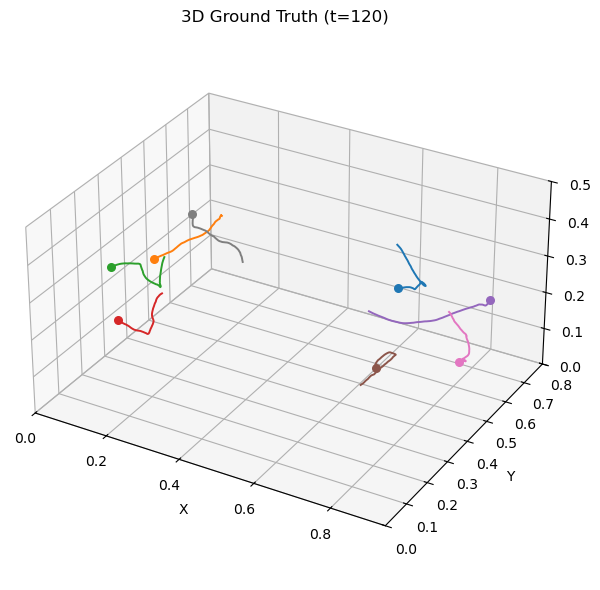

In [6]:
def plot_3d_ground_truth(
    pos3d: np.ndarray,
    tank_size: tuple[float, float, float],
    t_show: int | None = None,
    tail: int = 80,
):
    # Plot 3D trajectories and current positions
    T, N, _ = pos3d.shape
    Lx, Ly, Lz = tank_size

    if t_show is None:
        t_show = T - 1

    t0 = max(0, t_show - tail)

    fig = plt.figure(figsize=(8, 6))
    ax = fig.add_subplot(111, projection="3d")

    for i in range(N):
        tr = pos3d[t0:t_show + 1, i]
        ax.plot(tr[:, 0], tr[:, 1], tr[:, 2], linewidth=1.4)
        ax.scatter(pos3d[t_show, i, 0], pos3d[t_show, i, 1], pos3d[t_show, i, 2], s=30)

    ax.set_xlim(0, Lx)
    ax.set_ylim(0, Ly)
    ax.set_zlim(0, Lz)
    ax.set_xlabel("X")
    ax.set_ylabel("Y")
    ax.set_zlabel("Z")
    ax.set_title(f"3D Ground Truth (t={t_show})")
    ax.set_box_aspect([Lx, Ly, Lz])

    plt.tight_layout()
    plt.show()


plot_3d_ground_truth(
    pos3d=pos3d,
    tank_size=(sim.Lx, sim.Ly, sim.Lz),
    t_show=120,
    tail=80,
)

#Cell 7 — Save 3D ground truth

In [7]:
out_path = os.path.join(BASE_DIR, "synthetic_fish_3d_gt.npz")
sim.save_npz(out_path, traj, meta={"note": "3D GT + velocities"})
print("Saved:", out_path)

Saved: ./outputs/synthetic_fish_3d_gt.npz


#Cell 8 — Camera model

In [8]:
@dataclass
class Camera:
    # Pinhole camera with light radial distortion
    K: np.ndarray
    R: np.ndarray
    t: np.ndarray
    dist: tuple[float, float] = (-0.02, 0.0)
    image_size: tuple[int, int] = (3072, 3584)   # 8:7 -> (H, W)

    def world_to_cam(self, Xw: np.ndarray) -> np.ndarray:
        # World to camera coordinates
        return (Xw @ self.R.T) + self.t.reshape(1, 3)

    def project(self, Xw: np.ndarray) -> tuple[np.ndarray, np.ndarray]:
        # Project 3D points to the image plane
        Xc = self.world_to_cam(Xw)
        x, y, z = Xc[:, 0], Xc[:, 1], Xc[:, 2]

        xn = x / (z + 1e-9)
        yn = y / (z + 1e-9)

        k1, k2 = self.dist
        r2 = xn**2 + yn**2
        radial = 1.0 + k1 * r2 + k2 * (r2**2)

        xd = xn * radial
        yd = yn * radial

        fx, fy = self.K[0, 0], self.K[1, 1]
        cx, cy = self.K[0, 2], self.K[1, 2]

        u = fx * xd + cx
        v = fy * yd + cy

        uv = np.stack([u, v], axis=1)
        return uv, z

#Cell 9 — Camera helpers

In [9]:
def look_at_rotation(
    cam_pos: np.ndarray,
    target: np.ndarray,
    up: np.ndarray = np.array([0.0, 0.0, 1.0]),
) -> np.ndarray:
    # Camera rotation from position and target
    forward = normalize(target - cam_pos)
    right = normalize(np.cross(forward, up))

    if np.linalg.norm(right) < 1e-8:
        up = np.array([0.0, 1.0, 0.0])
        right = normalize(np.cross(forward, up))

    true_up = normalize(np.cross(right, forward))
    return np.stack([right, true_up, forward], axis=0)


def pinhole_intrinsics(
    image_size: tuple[int, int] = (3072, 3584),
    fov_deg: float = 90.0,
) -> np.ndarray:
    # Intrinsics for a normal low-distortion setup
    H, W = image_size
    fov = np.deg2rad(fov_deg)
    fx = (W / 2) / np.tan(fov / 2)
    fy = fx
    cx, cy = W / 2, H / 2

    return np.array([
        [fx, 0.0, cx],
        [0.0, fy, cy],
        [0.0, 0.0, 1.0],
    ], dtype=float)


def make_3_cameras_inside_tank(
    tank_size: tuple[float, float, float],
    image_size: tuple[int, int] = (3072, 3584),
    fov_deg: float = 90.0,
    dist: tuple[float, float] = (-0.02, 0.0),
    z_ratio: float = 0.96,            # just below surface
    inward_ratio_xy: float = 0.10,    # inside tank margins
    target_z_ratio: float = 0.55,     # diagonal downward view
) -> list[Camera]:
    # Create 3 cameras inside the tank
    Lx, Ly, Lz = tank_size
    K = pinhole_intrinsics(image_size=image_size, fov_deg=fov_deg)

    z_cam = z_ratio * Lz
    z_tgt = target_z_ratio * Lz
    mx = inward_ratio_xy * Lx
    my = inward_ratio_xy * Ly

    cam_positions = [
        np.array([mx,      my,      z_cam], dtype=float),
        np.array([Lx - mx, my,      z_cam], dtype=float),
        np.array([0.50*Lx, Ly - my, z_cam], dtype=float),
    ]

    targets = [
        np.array([0.45*Lx, 0.45*Ly, z_tgt], dtype=float),
        np.array([0.55*Lx, 0.45*Ly, z_tgt], dtype=float),
        np.array([0.50*Lx, 0.55*Ly, z_tgt], dtype=float),
    ]

    cams = []
    for cam_pos, target in zip(cam_positions, targets):
        R = look_at_rotation(cam_pos, target)
        t = -R @ cam_pos
        cams.append(Camera(K=K, R=R, t=t, dist=dist, image_size=image_size))

    return cams

#Cell 10 — Observation effects

In [10]:
def inside_image(uv: np.ndarray, H: int, W: int) -> np.ndarray:
    # Check image bounds
    u, v = uv[:, 0], uv[:, 1]
    return (u >= 0) & (u < W) & (v >= 0) & (v < H)


def apply_measurement_noise(
    uv: np.ndarray,
    sigma_px: float,
    rng: np.random.Generator,
    outlier_prob: float = 0.10,
    outlier_std: float = 40.0,
) -> tuple[np.ndarray, np.ndarray]:
    noise = rng.normal(0.0, sigma_px, size=uv.shape)

    outlier_mask = rng.random(uv.shape[0]) < outlier_prob  
    noise[outlier_mask] = rng.normal(0.0, outlier_std, size=(outlier_mask.sum(), 2))

    return uv + noise, outlier_mask


def apply_overlap_occlusion(
    uv: np.ndarray,
    depth: np.ndarray,
    overlap_radius_px: float = 42.0,
    occlusion_prob: float = 0.18,
    rng: np.random.Generator | None = None,
) -> np.ndarray:
    # More aggressive overlap and occlusion
    if rng is None:
        rng = np.random.default_rng(0)

    M = uv.shape[0]
    keep = np.ones(M, dtype=bool)
    order = np.argsort(depth)  # nearer fish first

    for i_idx in range(M):
        i = order[i_idx]
        if not keep[i]:
            continue

        for j_idx in range(i_idx + 1, M):
            j = order[j_idx]
            if not keep[j]:
                continue

            if np.linalg.norm(uv[i] - uv[j]) < overlap_radius_px:
                if rng.random() < occlusion_prob:
                    keep[j] = False

    return keep


def fragment_tracks(
    vis: np.ndarray,
    rng: np.random.Generator,
    fragment_prob: float = 0.012,
    min_gap: int = 2,
    max_gap: int = 8,
) -> np.ndarray:
    # Add longer, more frequent gaps to fragment tracks
    T, N = vis.shape
    vis2 = vis.copy()

    for n in range(N):
        t = 0
        while t < T:
            if vis2[t, n] and (rng.random() < fragment_prob):
                gap = rng.integers(min_gap, max_gap + 1)
                vis2[t:min(T, t + gap), n] = False
                t += gap
            else:
                t += 1

    return vis2

#Cell 11 — Main multiview generator

In [11]:
def generate_multiview_observations(
    pos3d: np.ndarray,
    cameras: list[Camera],
    sigma_px: float = 2.0,
    miss_prob: float = 0.02,
    overlap_radius_px: float = 42.0,
    occlusion_prob: float = 0.18,
    fragment_prob: float = 0.012,
    seed: int = 123,
) -> dict:
    rng = np.random.default_rng(seed)
    T, N, _ = pos3d.shape

    out = {"cameras": cameras, "pos3d_gt": pos3d}

    for cam_idx, cam in enumerate(cameras):
        H, W = cam.image_size

        uv_all   = np.full((T, N, 2), np.nan, dtype=float)
        z_all    = np.full((T, N),    np.nan, dtype=float)
        vis_all  = np.zeros((T, N),           dtype=bool)
        conf_all = np.zeros((T, N),           dtype=float)  # novo

        for t in range(T):
            uv, z = cam.project(pos3d[t])

            in_img  = inside_image(uv, H, W)
            in_front = z > 1e-3
            vis = in_img & in_front

            idx = np.where(vis)[0]
            if idx.size > 1:
                keep_local = apply_overlap_occlusion(
                    uv=uv[idx], depth=z[idx],
                    overlap_radius_px=overlap_radius_px,
                    occlusion_prob=occlusion_prob, rng=rng,
                )
                vis[idx[~keep_local]] = False

            vis &= (rng.random(N) >= miss_prob)

            uv_noisy = uv.copy()
            outlier_mask = np.zeros(N, dtype=bool) 
            if vis.any():
                uv_noisy[vis], outliers_vis = apply_measurement_noise(
                    uv_noisy[vis], sigma_px=sigma_px, rng=rng
                )
                outlier_mask[np.where(vis)[0][outliers_vis]] = True

            conf_all[t, vis & ~outlier_mask] = 1.0
            conf_all[t, vis &  outlier_mask] = 0.5
            conf_all[t, ~vis]                = 0.0

            uv_all[t, vis] = uv_noisy[vis]
            z_all[t]       = z
            vis_all[t]     = vis

        vis_all  = fragment_tracks(vis_all, rng=rng, fragment_prob=fragment_prob)
        conf_all[~vis_all] = 0.0  
        uv_all[~vis_all]   = np.nan

        out[f"cam{cam_idx}"] = {"uv": uv_all, "vis": vis_all, "z": z_all, "conf": conf_all}

    return out

#Cell 12 — Build 3 cameras and generate observations

In [12]:
# --- ENHANCED REALISTIC NOISY OBSERVATIONS ---
# Making the data much messier and more like real fish tank footage

tank_size = (sim.Lx, sim.Ly, sim.Lz)

# Ajuste conforme orientação do professor:
# Altura = 2040. Para 8:7, Largura = (2040 * 8) / 7 = 2331.4 -> arredondamos para 2332
IMAGE_WIDTH = 2332
IMAGE_HEIGHT = 2040

cams = make_3_cameras_inside_tank(
    tank_size=tank_size,
    image_size=(IMAGE_WIDTH, IMAGE_HEIGHT),
    fov_deg=90.0,
    dist=(-0.02, 0.0),
    z_ratio=0.96,
    inward_ratio_xy=0.10,
    target_z_ratio=0.55,
)

print(f"Câmeras configuradas com resolução: {IMAGE_WIDTH}x{IMAGE_HEIGHT} (Proporção 8:7)")
print("Number of cameras:", len(cams))

# GERANDO DADOS MUITO MAIS REALISTAS ("SUJOS")
obs = generate_multiview_observations(
    pos3d=pos3d,
    cameras=cams,
    sigma_px=14.0,          # INCREASED: High pixel noise (misalignment, motion blur, focus blur)
    miss_prob=0.20,         # INCREASED: 20% detection failures (real detector failures)
    overlap_radius_px=80.0, # INCREASED: Larger overlap radius (more fish crowding)
    occlusion_prob=0.50,    # INCREASED: 50% occlusion prob when overlapped (aggressive)
    fragment_prob=0.15,     # INCREASED: 15% track fragmentation rate
    seed=123,
)

print("✓ REALISTIC 'DIRTY' DATA GENERATED")
print("  - High measurement noise (σ=14px)")
print("  - 20% detection failures")
print("  - 50% occlusion probability")
print("  - 15% track fragmentation")

Câmeras configuradas com resolução: 2332x2040 (Proporção 8:7)
Number of cameras: 3
✓ REALISTIC 'DIRTY' DATA GENERATED
  - High measurement noise (σ=14px)
  - 20% detection failures
  - 50% occlusion probability
  - 15% track fragmentation


#Cell 13 — Sanity plot for the 3 cameras

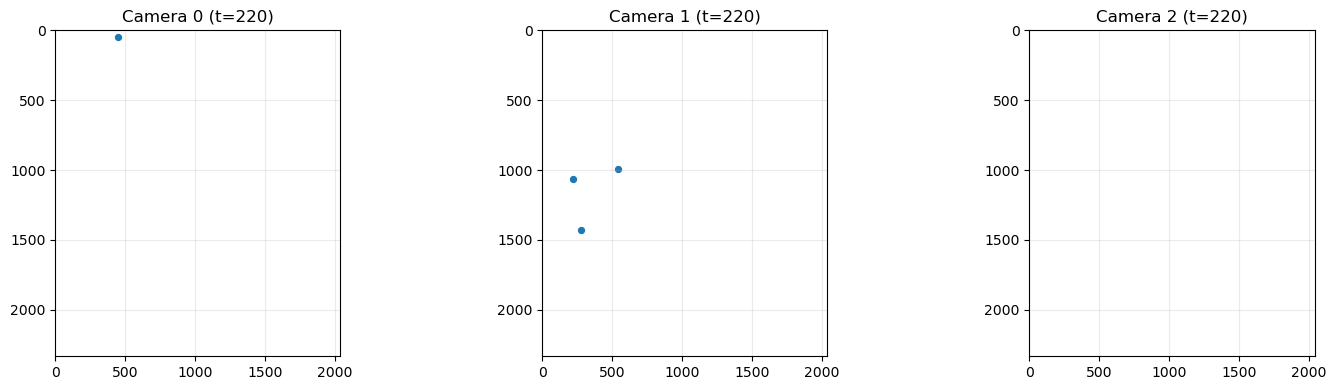

In [13]:
t_show = 220
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ci, ax in enumerate(axes):
    H, W = cams[ci].image_size
    uv = obs[f"cam{ci}"]["uv"][t_show]

    ax.set_title(f"Camera {ci} (t={t_show})")
    ax.set_xlim(0, W)
    ax.set_ylim(H, 0)
    ax.scatter(uv[:, 0], uv[:, 1], s=18)
    ax.set_aspect("equal", adjustable="box")
    ax.grid(True, alpha=0.25)

plt.tight_layout()
plt.show()

#Cell 14 — Save multiview dataset

In [14]:
out_path = os.path.join(BASE_DIR, "synthetic_fish_multiview_3cams_inside_tank.npz")

np.savez_compressed(
    out_path,
    tank_size=np.array(tank_size, dtype=float),
    pos3d_gt=pos3d,
    n_fish=pos3d.shape[1],
    image_size=np.array(cams[0].image_size, dtype=int),

    cam0_K=cams[0].K, cam0_R=cams[0].R, cam0_t=cams[0].t, cam0_dist=np.array(cams[0].dist),
    cam1_K=cams[1].K, cam1_R=cams[1].R, cam1_t=cams[1].t, cam1_dist=np.array(cams[1].dist),
    cam2_K=cams[2].K, cam2_R=cams[2].R, cam2_t=cams[2].t, cam2_dist=np.array(cams[2].dist),

    cam0_uv=obs["cam0"]["uv"], cam0_vis=obs["cam0"]["vis"], cam0_z=obs["cam0"]["z"], cam0_conf=obs["cam0"]["conf"],
    cam1_uv=obs["cam1"]["uv"], cam1_vis=obs["cam1"]["vis"], cam1_z=obs["cam1"]["z"], cam1_conf=obs["cam1"]["conf"],
    cam2_uv=obs["cam2"]["uv"], cam2_vis=obs["cam2"]["vis"], cam2_z=obs["cam2"]["z"], cam2_conf=obs["cam2"]["conf"],
)

print("Saved:", out_path)

Saved: ./outputs/synthetic_fish_multiview_3cams_inside_tank.npz


#Cell 15 — Load data for video rendering

In [15]:
data = np.load(os.path.join(BASE_DIR, "synthetic_fish_multiview_3cams_inside_tank.npz"))

H, W = map(int, data["image_size"])
print("Render size:", (H, W))
print("Fish count:", int(data["n_fish"]))

Render size: (2332, 2040)
Fish count: 8


#Cell 16 — Rendering style

In [16]:
BG_COLOR = (20, 90, 170)
FISH_COLOR = (240, 240, 240)

ELL_A = 24
ELL_B = 10

FPS_OUT = 15
REPEAT_EACH_FRAME = 2

#Cell 17 — Drawing helper

In [17]:
def draw_rotated_ellipse(
    img: np.ndarray,
    cx: int,
    cy: int,
    a: int,
    b: int,
    theta: float,
    color: tuple[int, int, int],
):
    # Draw a filled rotated ellipse
    H_, W_ = img.shape[:2]

    r = int(math.ceil(max(a, b))) + 2
    x0 = max(0, cx - r)
    x1 = min(W_, cx + r + 1)
    y0 = max(0, cy - r)
    y1 = min(H_, cy + r + 1)

    if x0 >= x1 or y0 >= y1:
        return

    yy, xx = np.mgrid[y0:y1, x0:x1]
    x = xx - cx
    y = yy - cy

    ct = math.cos(theta)
    st = math.sin(theta)

    xr =  ct * x + st * y
    yr = -st * x + ct * y

    mask = (xr**2) / (a**2 + 1e-9) + (yr**2) / (b**2 + 1e-9) <= 1.0
    img[y0:y1, x0:x1][mask] = color

#Cell 18 — Render one camera

In [18]:
def render_camera_video(cam_id: int, out_name: str):
    # Render one camera view as video using OpenCV
    uv = data[f"cam{cam_id}_uv"]
    vis = data[f"cam{cam_id}_vis"]
    T, N, _ = uv.shape

    # OpenCV VideoWriter setup
    fourcc = cv2.VideoWriter_fourcc(*'mp4v')  # or 'MJPG', 'XVID'
    fps = FPS_OUT * REPEAT_EACH_FRAME
    writer = cv2.VideoWriter(out_name, fourcc, fps, (W, H))

    for t in range(T):
        frame = np.zeros((H, W, 3), dtype=np.uint8)
        frame[..., 0] = BG_COLOR[0]
        frame[..., 1] = BG_COLOR[1]
        frame[..., 2] = BG_COLOR[2]

        idx = np.where(vis[t])[0]
        for fish_id in idx:
            pt = uv[t, fish_id]
            if not np.isfinite(pt).all():
                continue

            u, v = pt
            cx, cy = int(round(u)), int(round(v))
            if not (0 <= cx < W and 0 <= cy < H):
                continue

            theta = 0.0
            speed = 0.0

            if t > 0 and vis[t - 1, fish_id] and np.isfinite(uv[t - 1, fish_id]).all():
                du = uv[t, fish_id, 0] - uv[t - 1, fish_id, 0]
                dv = uv[t, fish_id, 1] - uv[t - 1, fish_id, 1]
                theta = math.atan2(dv, du)
                speed = math.hypot(du, dv)

            a = ELL_A + min(12, int(speed * 0.5))
            b = ELL_B

            draw_rotated_ellipse(
                img=frame,
                cx=cx,
                cy=cy,
                a=a,
                b=b,
                theta=theta,
                color=FISH_COLOR,
            )

        # OpenCV uses BGR, convert from RGB
        frame_bgr = cv2.cvtColor(frame, cv2.COLOR_RGB2BGR)
        
        for _ in range(REPEAT_EACH_FRAME):
            writer.write(frame_bgr)

    writer.release()
    print("Saved:", out_name)

#Cell 19 — Render all 3 videos

In [19]:
for cam_id in [0, 1, 2]:
    out_name = os.path.join(BASE_DIR, f"camera_{cam_id}_inside_tank.mp4")
    render_camera_video(cam_id, out_name)

Saved: ./outputs/camera_0_inside_tank.mp4
Saved: ./outputs/camera_1_inside_tank.mp4
Saved: ./outputs/camera_2_inside_tank.mp4


In [20]:
###check
assert np.all(pos3d[:, :, 0] >= 0) and np.all(pos3d[:, :, 0] <= sim.Lx)
assert np.all(pos3d[:, :, 1] >= 0) and np.all(pos3d[:, :, 1] <= sim.Ly)
assert np.all(pos3d[:, :, 2] >= 0) and np.all(pos3d[:, :, 2] <= sim.Lz)

print("All fish remain inside the tank in 3D.")

All fish remain inside the tank in 3D.


#Cell 20 — Final checks

In [21]:
print("Final checks")
print("3 cameras:", len(cams))
print("8 fish:", pos3d.shape[1])
print("Image size:", cams[0].image_size)
print("Dataset file:", os.path.join(BASE_DIR, "synthetic_fish_multiview_3cams_inside_tank.npz"))
print(pos3d.shape)

Final checks
3 cameras: 3
8 fish: 8
Image size: (2332, 2040)
Dataset file: ./outputs/synthetic_fish_multiview_3cams_inside_tank.npz
(600, 8, 3)


In [22]:
import subprocess
from PIL import Image

def render_videos_with_ffmpeg():
    """Render videos using ffmpeg (more reliable than opencv/imageio)"""
    
    data = np.load(os.path.join(BASE_DIR, "synthetic_fish_multiview_3cams_inside_tank.npz"))
    
    for cam_id in [0, 1, 2]:
        print(f"\n--- Rendering Camera {cam_id} ---")
        
        uv = data[f"cam{cam_id}_uv"]
        vis = data[f"cam{cam_id}_vis"]
        T, N, _ = uv.shape
        
        # Temporary directory for frames
        frames_dir = os.path.join(BASE_DIR, f"frames_cam{cam_id}")
        os.makedirs(frames_dir, exist_ok=True)
        
        # Render frames
        print(f"Rendering {T} frames...")
        for t in range(T):
            frame = np.zeros((H, W, 3), dtype=np.uint8)
            frame[..., 0] = BG_COLOR[0]
            frame[..., 1] = BG_COLOR[1]
            frame[..., 2] = BG_COLOR[2]

            idx = np.where(vis[t])[0]
            for fish_id in idx:
                pt = uv[t, fish_id]
                if not np.isfinite(pt).all():
                    continue

                u, v = pt
                cx, cy = int(round(u)), int(round(v))
                if not (0 <= cx < W and 0 <= cy < H):
                    continue

                theta = 0.0
                speed = 0.0

                if t > 0 and vis[t - 1, fish_id] and np.isfinite(uv[t - 1, fish_id]).all():
                    du = uv[t, fish_id, 0] - uv[t - 1, fish_id, 0]
                    dv = uv[t, fish_id, 1] - uv[t - 1, fish_id, 1]
                    theta = math.atan2(dv, du)
                    speed = math.hypot(du, dv)

                a = ELL_A + min(12, int(speed * 0.5))
                b = ELL_B

                draw_rotated_ellipse(
                    img=frame,
                    cx=cx,
                    cy=cy,
                    a=a,
                    b=b,
                    theta=theta,
                    color=FISH_COLOR,
                )

            # Save frame as PNG
            img_pil = Image.fromarray(frame)
            img_pil.save(os.path.join(frames_dir, f"frame_{t:06d}.png"))
            
            if (t + 1) % 100 == 0:
                print(f"  Rendered {t + 1}/{T} frames")

        # Use ffmpeg to create video from frames
        output_path = os.path.join(BASE_DIR, f"camera_{cam_id}_inside_tank.mp4")
        frames_pattern = os.path.join(frames_dir, "frame_%06d.png")
        
        print(f"Creating video with ffmpeg...")
        cmd = [
            "ffmpeg",
            "-framerate", str(FPS_OUT),
            "-i", frames_pattern,
            "-c:v", "libx264",
            "-pix_fmt", "yuv420p",
            "-y",  # Overwrite output file
            output_path
        ]
        
        result = subprocess.run(cmd, capture_output=True, text=True)
        
        if result.returncode == 0:
            print(f"✓ Saved: {output_path}")
        else:
            print(f"✗ Error: {result.stderr}")
        
        # Clean up frames
        import shutil
        shutil.rmtree(frames_dir)
        print(f"  Cleaned up temporary frames")

# Run rendering
render_videos_with_ffmpeg()
print("\n✓ All videos rendered!")



--- Rendering Camera 0 ---
Rendering 600 frames...
  Rendered 100/600 frames
  Rendered 200/600 frames
  Rendered 300/600 frames
  Rendered 400/600 frames
  Rendered 500/600 frames
  Rendered 600/600 frames
Creating video with ffmpeg...
✓ Saved: ./outputs/camera_0_inside_tank.mp4
  Cleaned up temporary frames

--- Rendering Camera 1 ---
Rendering 600 frames...
  Rendered 100/600 frames
  Rendered 200/600 frames
  Rendered 300/600 frames
  Rendered 400/600 frames
  Rendered 500/600 frames
  Rendered 600/600 frames
Creating video with ffmpeg...
✓ Saved: ./outputs/camera_1_inside_tank.mp4
  Cleaned up temporary frames

--- Rendering Camera 2 ---
Rendering 600 frames...
  Rendered 100/600 frames
  Rendered 200/600 frames
  Rendered 300/600 frames
  Rendered 400/600 frames
  Rendered 500/600 frames
  Rendered 600/600 frames
Creating video with ffmpeg...
✓ Saved: ./outputs/camera_2_inside_tank.mp4
  Cleaned up temporary frames

✓ All videos rendered!
